In [1]:
# librerías
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import mplfinance as mpf
import ta

In [ ]:
# parte 1
# descarga de datos ETH
df = yf.download("ETH-USD", start="2019-09-01", end="2021-09-01")
df.columns = df.columns.droplevel(1)

df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2019-09-01,171.629425,173.696854,169.531281,172.458405,5554799576
2019-09-02,178.347351,180.145218,170.451691,171.697601,6503447137
2019-09-03,179.499329,182.347992,175.970169,178.357758,6962728938
2019-09-04,175.992889,180.136597,175.325363,179.491989,5938120494
2019-09-05,174.217133,176.163910,171.746826,175.966278,5589476516
...,...,...,...,...,...
2021-08-27,3270.600830,3281.840576,3064.485107,3096.406006,18489602004
2021-08-28,3244.403320,3284.845947,3217.403564,3275.104492,13709633698
2021-08-29,3227.002686,3283.235596,3158.840332,3246.770996,13296586731


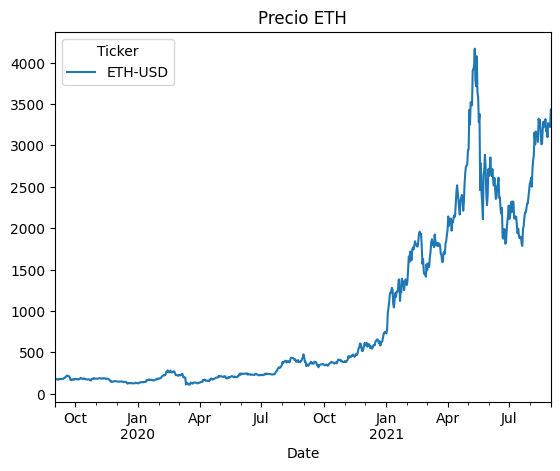

In [3]:
#grafico de precios 
df['Close'].plot(title='Precio ETH')
plt.show()

In [28]:
# retornos
df['ret_arit'] = df['Close'].pct_change()
df['ret_log'] = np.log(df['Close'] / df['Close'].shift(1))

df

Price,Close,High,Low,Open,Volume,ret_arit,ret_log
Date,,,,,,,
2019-09-01,171.629425,173.696854,169.531281,172.458405,5554799576,NaN,NaN
2019-09-02,178.347351,180.145218,170.451691,171.697601,6503447137,0.039142,0.038395
2019-09-03,179.499329,182.347992,175.970169,178.357758,6962728938,0.006459,0.006438
2019-09-04,175.992889,180.136597,175.325363,179.491989,5938120494,-0.019535,-0.019728
2019-09-05,174.217133,176.163910,171.746826,175.966278,5589476516,-0.010090,-0.010141
...,...,...,...,...,...,...,...
2021-08-27,3270.600830,3281.840576,3064.485107,3096.406006,18489602004,0.054922,0.053467
2021-08-28,3244.403320,3284.845947,3217.403564,3275.104492,13709633698,-0.008010,-0.008042
2021-08-29,3227.002686,3283.235596,3158.840332,3246.770996,13296586731,-0.005363,-0.005378


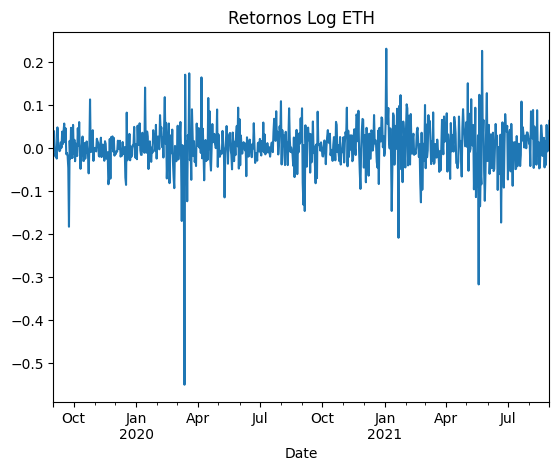

In [5]:
#grafico retornos logaritmicos 
df['ret_log'].plot(title='Retornos Log ETH')
plt.show()

In [6]:
#Promedio anualizado de los retornos logaritmicos
mean_log = df['ret_log'].mean() * 252
mean_log

np.float64(1.034258241992127)

In [7]:
#Volatilidad anualizada de los retornos logaritmicos
vol = df['ret_log'].std() * np.sqrt(252)
vol

np.float64(0.8471734999624263)

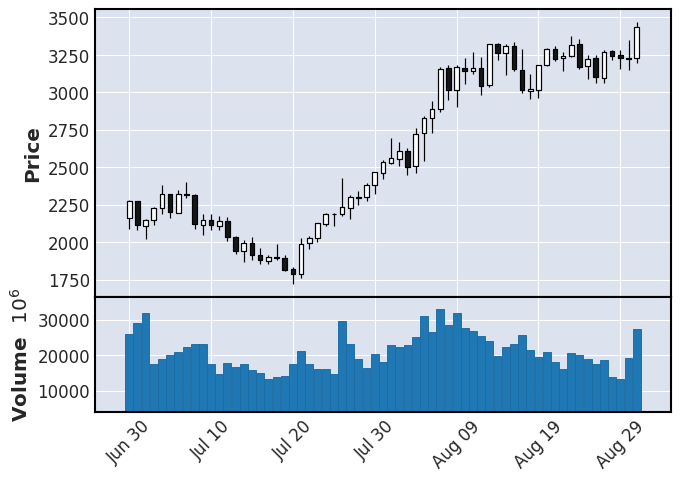

In [ ]:
#parte 2
#grafico de velas
mpf.plot(df.tail(63), type='candle', volume=True)

In [30]:
sp = yf.download("^GSPC", start="2019-09-01", end="2021-09-01")

# escalar
eth_scaled = df['Close'] / df['Close'].iloc[0] * 100
sp_scaled = sp['Close'] / sp['Close'].iloc[0] * 100

[*********************100%***********************]  1 of 1 completed


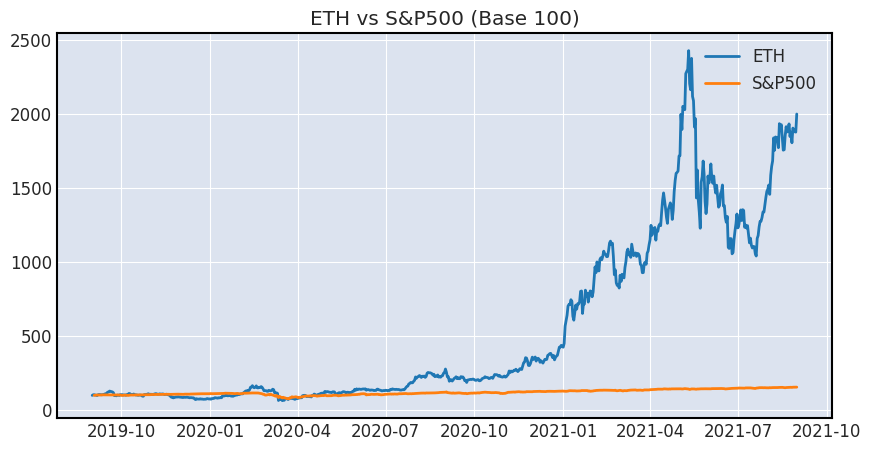

In [31]:
plt.figure(figsize=(10,5))
plt.plot(eth_scaled, label='ETH')
plt.plot(sp_scaled, label='S&P500')
plt.legend()
plt.title('ETH vs S&P500 (Base 100)')
plt.show()

In [32]:
#parte 3
df['EMA_5'] = ta.trend.ema_indicator(df['Close'], window=5)
df['EMA_20'] = ta.trend.ema_indicator(df['Close'], window=20)

In [33]:
df['Signals'] = np.where(df['EMA_5'] > df['EMA_20'], 1, -1)

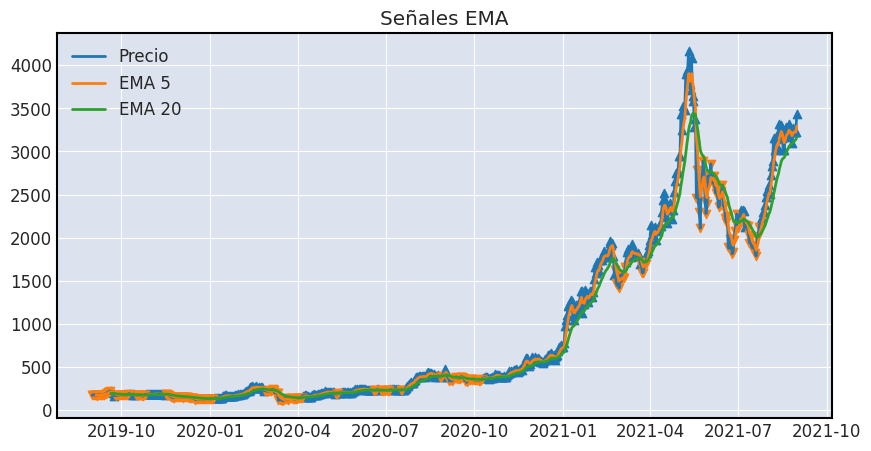

In [ ]:
# gráfico de precios con EMAs y señales
plt.figure(figsize=(10,5))

plt.plot(df['Close'], label='Precio')
plt.plot(df['EMA_5'], label='EMA 5')
plt.plot(df['EMA_20'], label='EMA 20')

plt.scatter(df.index[df['Signals'] == 1], df['Close'][df['Signals'] == 1], marker='^')
plt.scatter(df.index[df['Signals'] == -1], df['Close'][df['Signals'] == -1], marker='v')

plt.legend()
plt.title('Señales EMA')
plt.show()

In [35]:
# parte 4
# indicadores técnicos adicionales
df['EMA_5'] = ta.trend.ema_indicator(df['Close'], window=5)
df['EMA_20'] = ta.trend.ema_indicator(df['Close'], window=20)
df['EMA_50'] = ta.trend.ema_indicator(df['Close'], window=50)
df['EMA_100'] = ta.trend.ema_indicator(df['Close'], window=100)

df['RSI'] = ta.momentum.rsi(df['Close'])

df['ATR'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'])

df['Williams'] = ta.momentum.williams_r(df['High'], df['Low'], df['Close'])

In [36]:
cl = np.array(df['Close'])
target = np.where(cl[1:] > cl[:-1], 1, -1)

df = df.iloc[:-1]
df['Target'] = target

In [37]:
df = df.dropna()

In [38]:
X = df[['EMA_5','EMA_20','EMA_50','EMA_100','RSI','ATR','Williams']]
Y = df['Target']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.1, shuffle=False
)

In [40]:
#modelo random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, Y_train)

rf_pred = rf.predict_proba(X_test)[:,1]

In [41]:
#modelo MLP
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000, solver='adam')
mlp.fit(X_train, Y_train)

mlp_pred = mlp.predict_proba(X_test)[:,1]

In [42]:
from sklearn.metrics import roc_auc_score

auc_rf = roc_auc_score(Y_test, rf_pred)
auc_mlp = roc_auc_score(Y_test, mlp_pred)

print("AUC RF:", auc_rf)
print("AUC MLP:", auc_mlp)

AUC RF: 0.4969635627530365
AUC MLP: 0.5010121457489879
